In [1]:
import pandas as pd
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

df = pd.read_json("books_dirty_2.json")

# Replace "" with np.nan
df = df.replace("", np.nan)


# For certain columns,   we can force convert all values to numeric, or NaN if not possible. Final dtype will be float
cols = ["publication_year", "page_count", "average_rating", "ratings_count", "price_usd", "sales_millions"]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Normalize dates in last_checkout
df["last_checkout"] = pd.to_datetime(df["last_checkout"], format="mixed", errors="coerce")

# Clamp publication year between 1800 and 2026
df = df[(df["publication_year"] >= 1800) & (df["publication_year"] <= 2026)]

# Ensure realistic values for page count
df = df[df["page_count"] > 0]

# Ensure realistic values for average_rating
df = df[(df["average_rating"] >= 0.0) & (df["average_rating"] <= 5.0)]

# Ensure realistic values ratings_count, price_usd and sales_million
df = df[
    (df["ratings_count"].fillna(0) >= 0) & 
    (df["price_usd"].fillna(0) >= 0) & 
    (df["sales_millions"].fillna(0) >= 0)
]
cols = ["genre", "language", "format", "publisher"]
df[cols] = df[cols].apply(lambda x: x.str.capitalize())

df = df.drop_duplicates(subset=["title", "author"])

df['publisher_email'] = df['publisher_email'].str.replace(r'\.[^.]+$', '.com', regex=True)

# df is now cleaned!





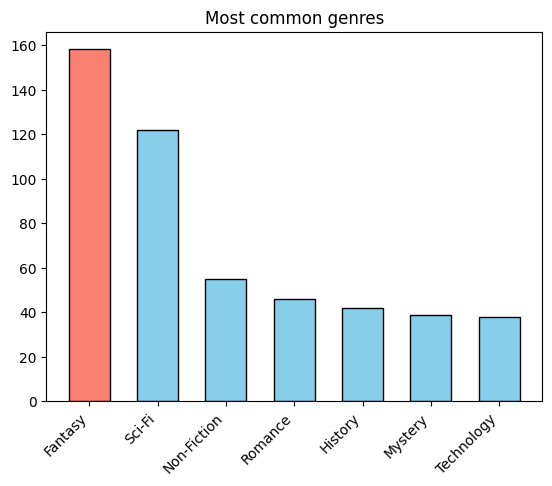

In [2]:
# Most common genres
from matplotlib import pyplot as plt
df = pd.read_json("books.json")
genre_counts = df.groupby('genre').size().sort_values(ascending=False)

most_common = genre_counts.max()
colors = ['salmon' if v == most_common else 'skyblue' for v in genre_counts.values]

plt.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black', width=0.6)
plt.xticks(rotation=45, ha='right')
plt.title("Most common genres")
plt.show()

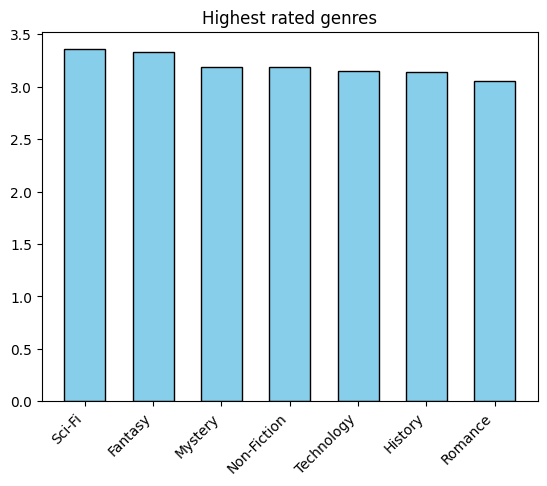

In [3]:
# Highest rated genres

def calculate_weighted_rating(group, C, m=50):

    # Bayesian Average formula:
    # weighted_rating = (median_ratings_count / (median_ratings_count + m)) * mean_average_rating + (m / (median_ratings_count + m)) * mean_average_rating_all_books

    median_ratings_count = group['ratings_count'].sum()
    mean_average_rating = group['average_rating'].mean()
   
    return (median_ratings_count / (median_ratings_count + m) * mean_average_rating) + (m / (median_ratings_count + m) * mean_average_rating_all_books)

mean_average_rating_all_books = df['average_rating'].mean()
genre_counts = df.groupby('genre').apply(lambda x: calculate_weighted_rating(x, mean_average_rating_all_books)).sort_values(ascending=False)
plt.bar(genre_counts.index, genre_counts.values, color='skyblue', edgecolor='black', width=0.6)
plt.xticks(rotation=45, ha='right')
plt.title("Highest rated genres")
plt.show()

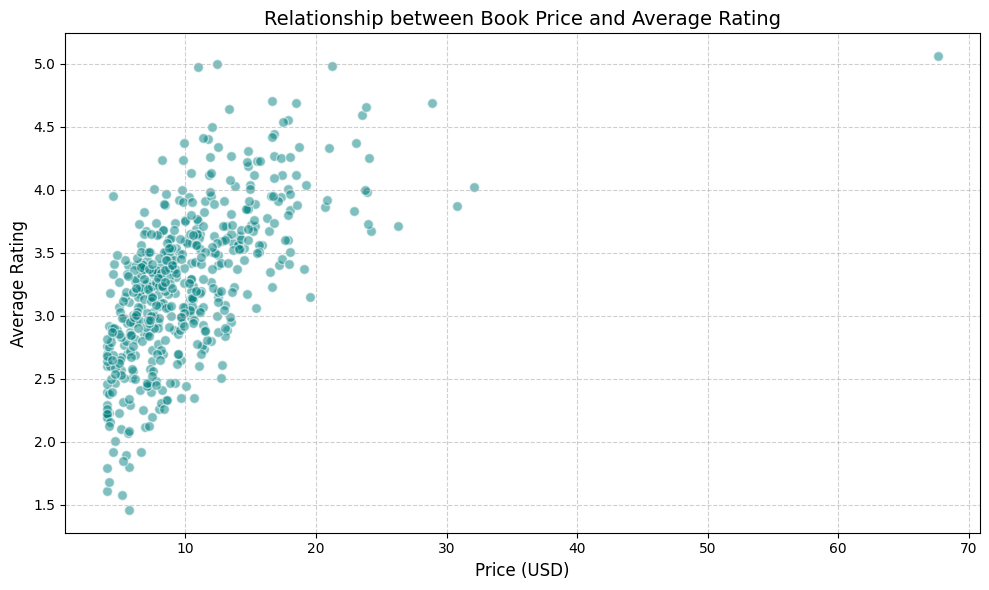

In [4]:
# Scatter plot that shows if higher priced books have better ratings

plt.figure(figsize=(10, 6))
plt.scatter(
    df['price_usd'], 
    df['average_rating'], 
    alpha=0.5,
    color='teal',
    edgecolor='white',
    s=50
)

plt.title('Relationship between Book Price and Average Rating', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# We can see a clear positive correlation between average rating and the price of the book

Text(0.5, 1.0, 'Books released by year')

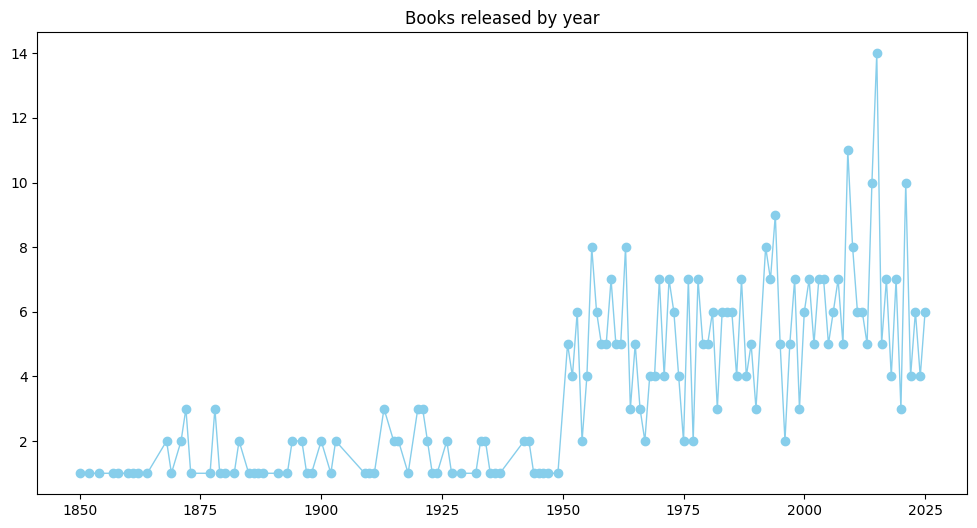

In [5]:
# Line chart to show books released by year

year_counts = df.groupby('publication_year').size().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, 
         marker='o',           
         linestyle='-',
         linewidth=1,
         color='skyblue')

plt.title("Books released by year")

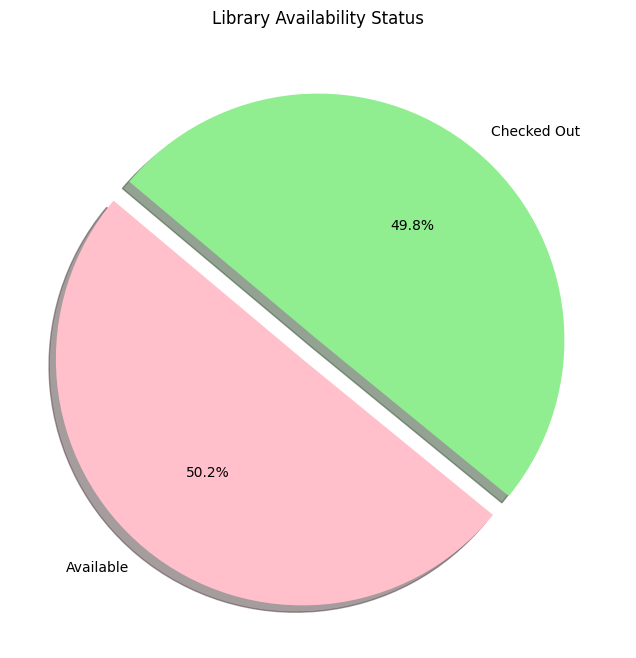

In [6]:
# Pie chart to show checked in vs. chekced out books

status_counts = df['available'].value_counts()
labels = ['Available' if x else 'Checked Out' for x in status_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(
    status_counts, 
    labels=labels, 
    autopct='%1.1f%%',
    startangle=140,
    colors=['pink','lightgreen'],
    explode=(0.1, 0),
    shadow=True
)

plt.title('Library Availability Status')
plt.show()